TEACHER JOB SATISFACTION USING ML TECHNIQUES

1. Problem Statement


Teacher job satisfaction strongly influences institutional performance, teacher retention, and the quality of education. However, it is affected by multiple factors such as workload, burnout, administrative support, and work-life balance. Traditional statistical methods often miss complex relationships, highlighting the need for machine learning–based approaches to identify key determinants and accurately predict satisfaction levels

2. Data Collection

The dataset used in this study was collected as primary data through a structured questionnaire created using Google Forms. The survey was distributed to teachers to gather information related to job satisfaction, workload, burnout, administrative support, and work-life balance. A total of 124 responses were received and recorded for analysis. The collected data was then organized and prepared for further processing, statistical analysis, and machine learning model development.

Importing libraries

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re


In [34]:
df = pd.read_excel("/content/dataset.xlsx")

# Drop missing values (or impute)
df = df.dropna()
df.head()

,Age group,Gender,Years of teaching experience,Type of institution,Average working hours per week,Overall job satisfaction,Satisfaction with salary,Satisfaction with work-life balance,Satisfaction with administrative support,Satisfaction with career growth opportunities,...,I experience burnout symptoms regularly,Difficulty managing student behaviour,Pressure from student performance expectations,Digital teaching workload,Difficulty adapting to new-generation learners,I maintain a healthy work-life balance,My job negatively affects my personal life,I feel valued at my workplace,I feel mentally well most days,24. What is the biggest challenge you face as a teacher?
0,20–30,Female,0–5,Private school,40–50,4.0,2.0,3.0,3.0,3.0,...,3.0,3.0,3.0,3.0,3.0,3.0,2.0,3.0,3.0,NIL
1,51+,Female,20+,Government school,40–50,5.0,5.0,5.0,4.0,4.0,...,1.0,3.0,2.0,4.0,4.0,4.0,1.0,4.0,4.0,NIL
2,31–40,Female,6–10,Private school,Less than 40,3.0,3.0,1.0,4.0,4.0,...,1.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,"As a teacher, the biggest challenge I face is ..."
3,31–40,Female,6–10,Private school,40–50,3.0,3.0,3.0,4.0,1.0,...,3.0,2.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,New gen andlack of time in portions completion
4,20–30,Female,0–5,Private school,Less than 40,2.0,2.0,1.0,2.0,3.0,...,4.0,2.0,2.0,1.0,1.0,3.0,1.0,3.0,3.0,Less Salary


3. Data Preprocessing

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Function to clean column names
def clean_col_name(col_name):
    # Remove numbers and periods at the beginning (e.g., "1. " or "2. ")
    col_name = re.sub(r'^\d+\.\s*', '', col_name)
    # Replace spaces with underscores
    col_name = col_name.replace(' ', '_')
    # Convert to lowercase
    col_name = col_name.lower()
    # Remove leading/trailing underscores
    col_name = col_name.strip('_')
    # Replace multiple underscores with a single one
    col_name = re.sub(r'_{2,}', '_', col_name)
    return col_name

# Apply cleaning to all columns
df.columns = [clean_col_name(col) for col in df.columns]

# Find the exact column name for 'overall_job_satisfaction' after cleaning
# This assumes there is only one column related to 'overall_job_satisfaction'
target_col_name = None
for col in df.columns:
    if 'overall_job_satisfaction' in col:
        target_col_name = col
        break

if target_col_name is None:
    raise KeyError("Could not find a column related to 'overall_job_satisfaction' after cleaning.")

# Now, select the target variable and features using the identified name
y = df[target_col_name]
X = df.drop(columns=[target_col_name])

# Convert categorical features to numerical using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

4.EDA

/tmp/ipykernel_1134/155038600.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='age_group', ax=axes[0, 0], palette='viridis')
/tmp/ipykernel_1134/155038600.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='gender', ax=axes[0, 1], palette='magma')
/tmp/ipykernel_1134/155038600.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='years_of_teaching_experience', ax=axes[1, 0], palette='cubehelix')
/tmp/ipykernel_1134/155038600.py:40: FutureWarning: 

Passing `palette` without assi

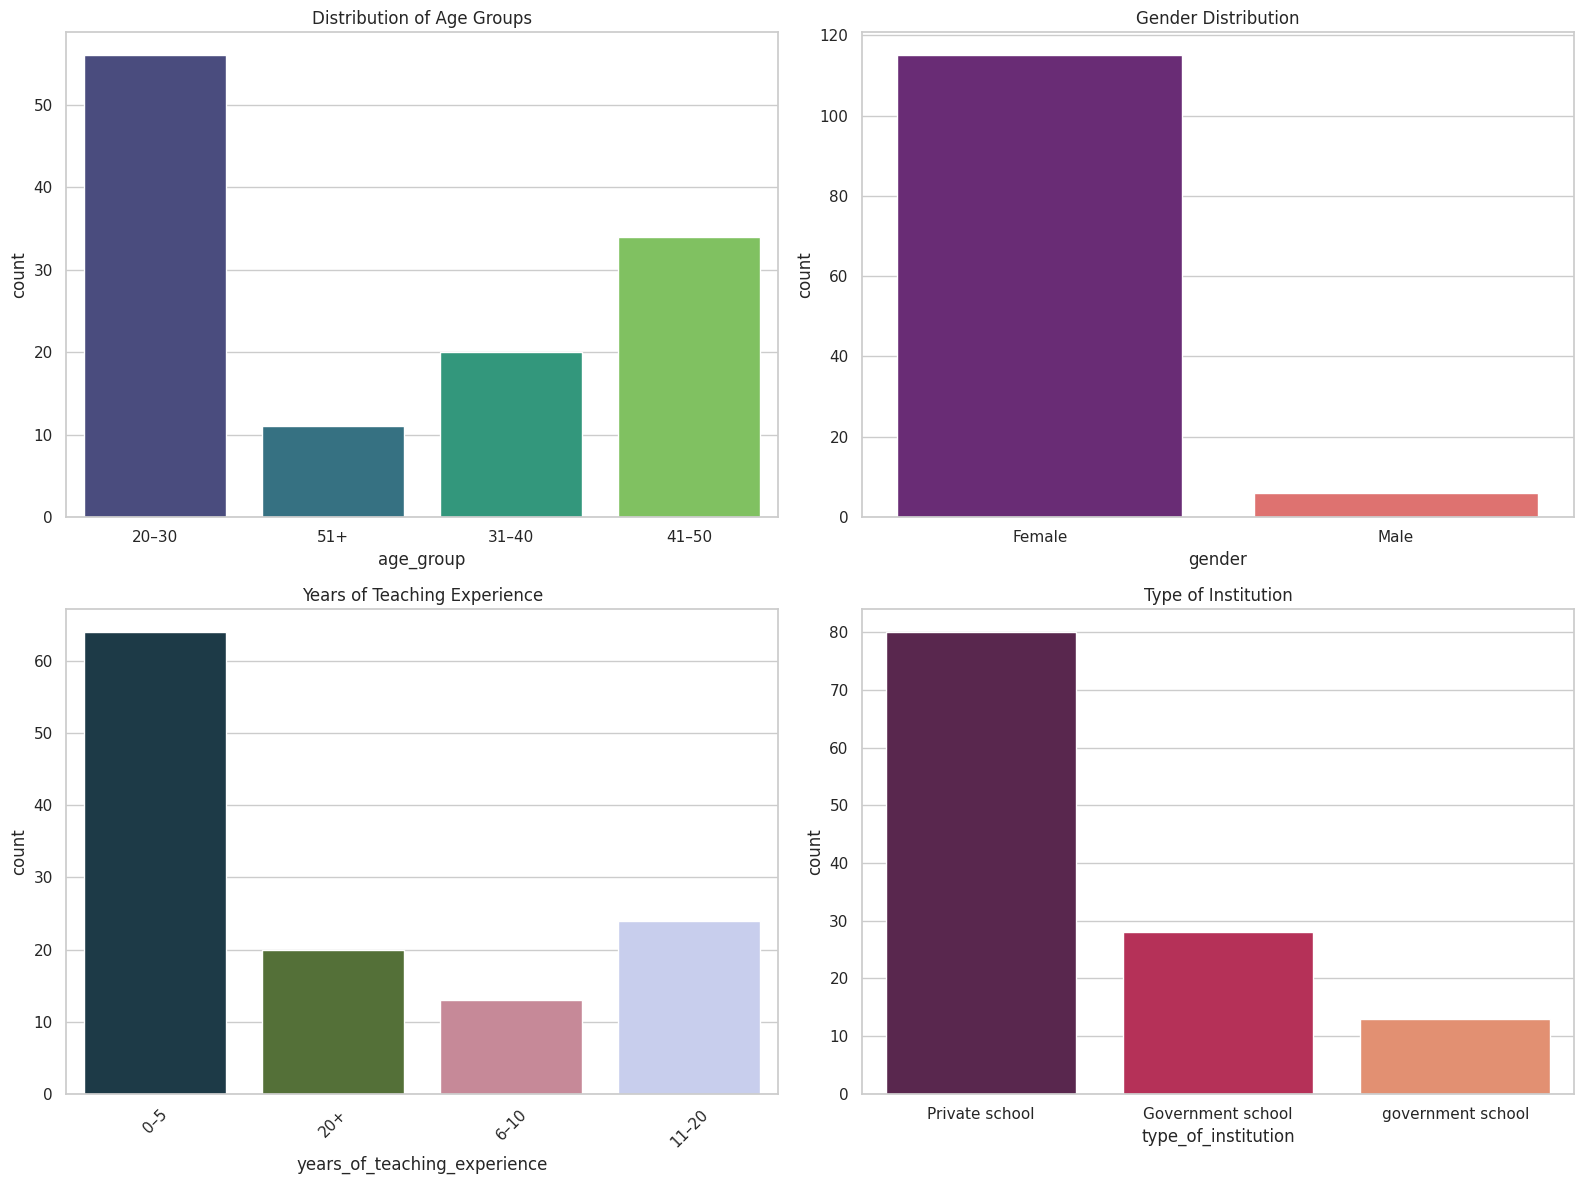

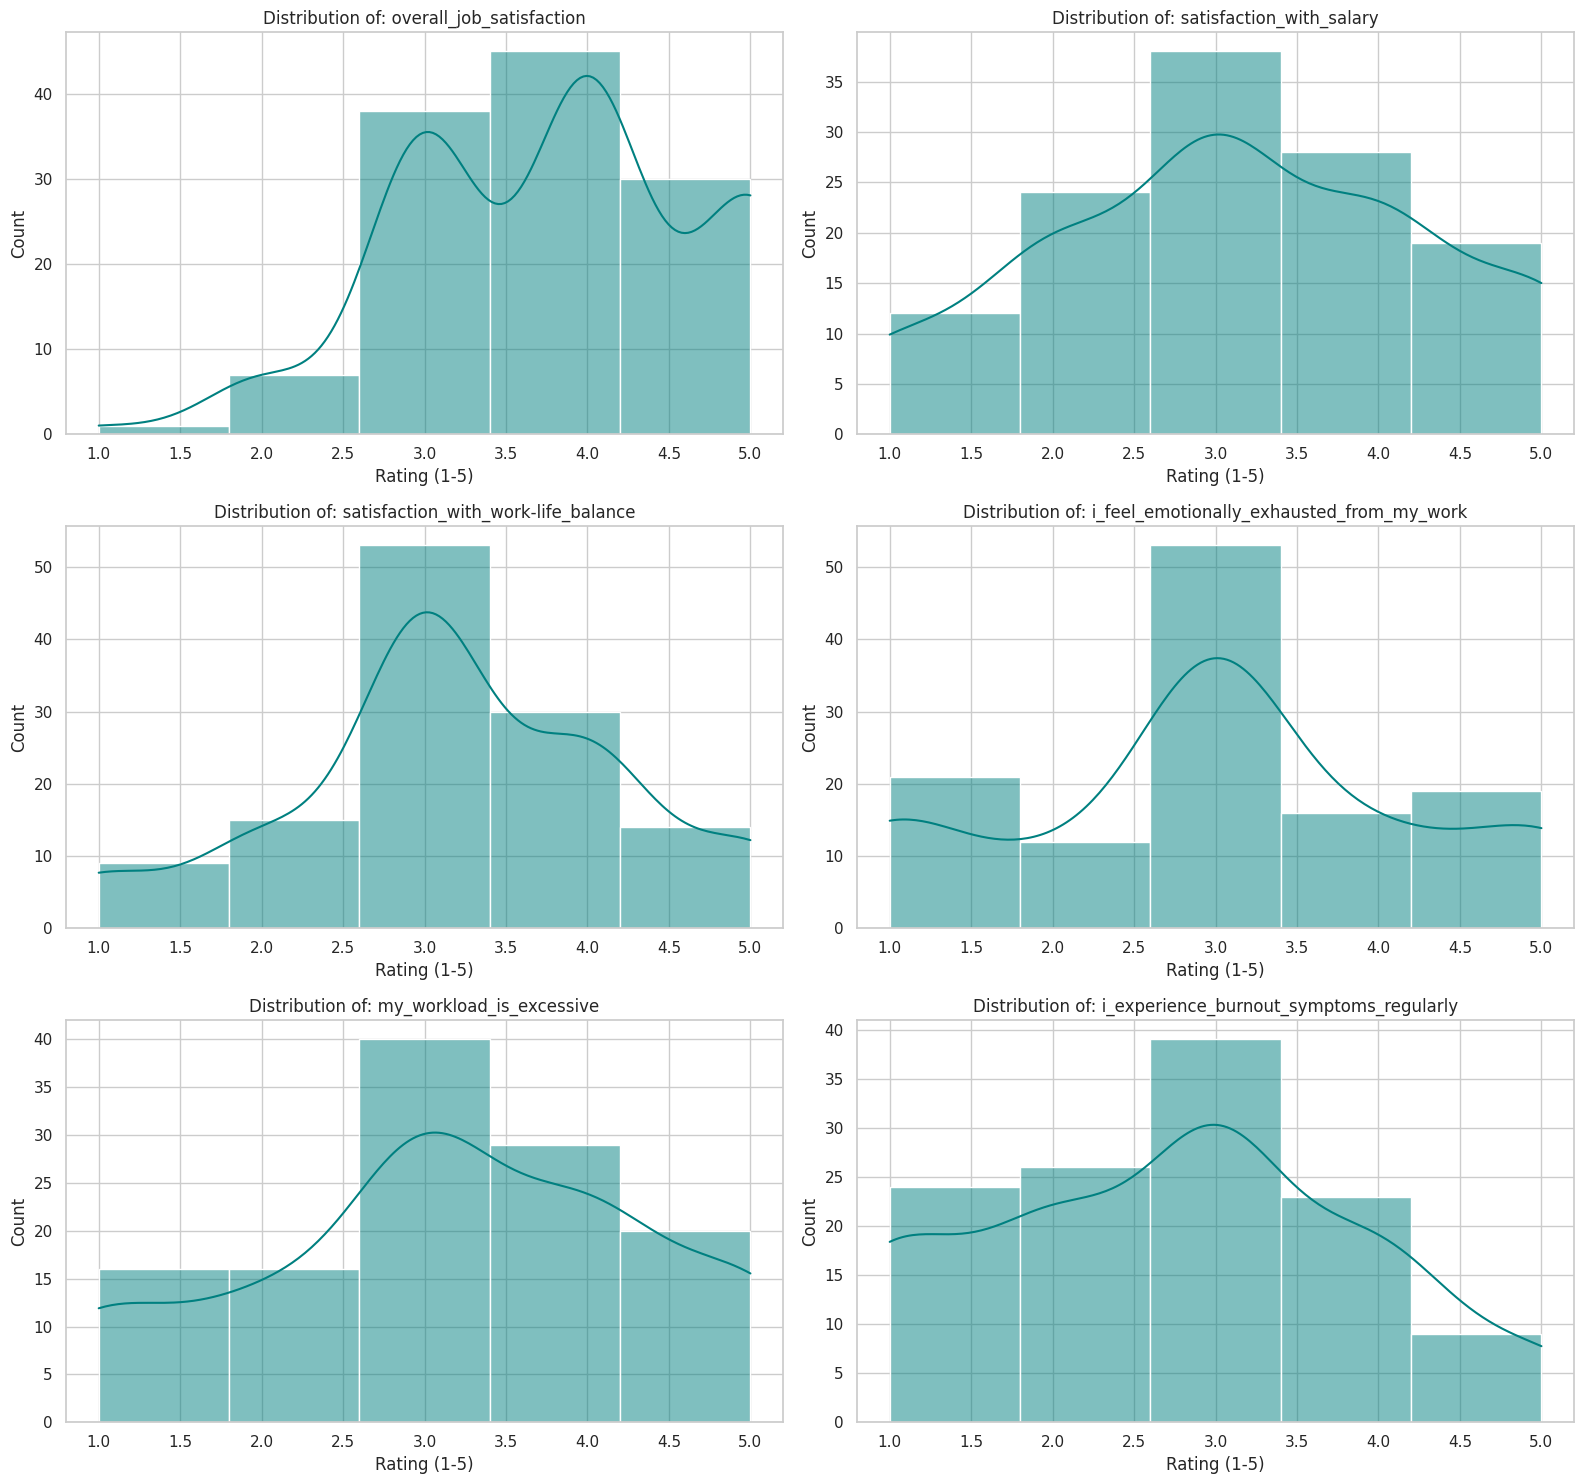

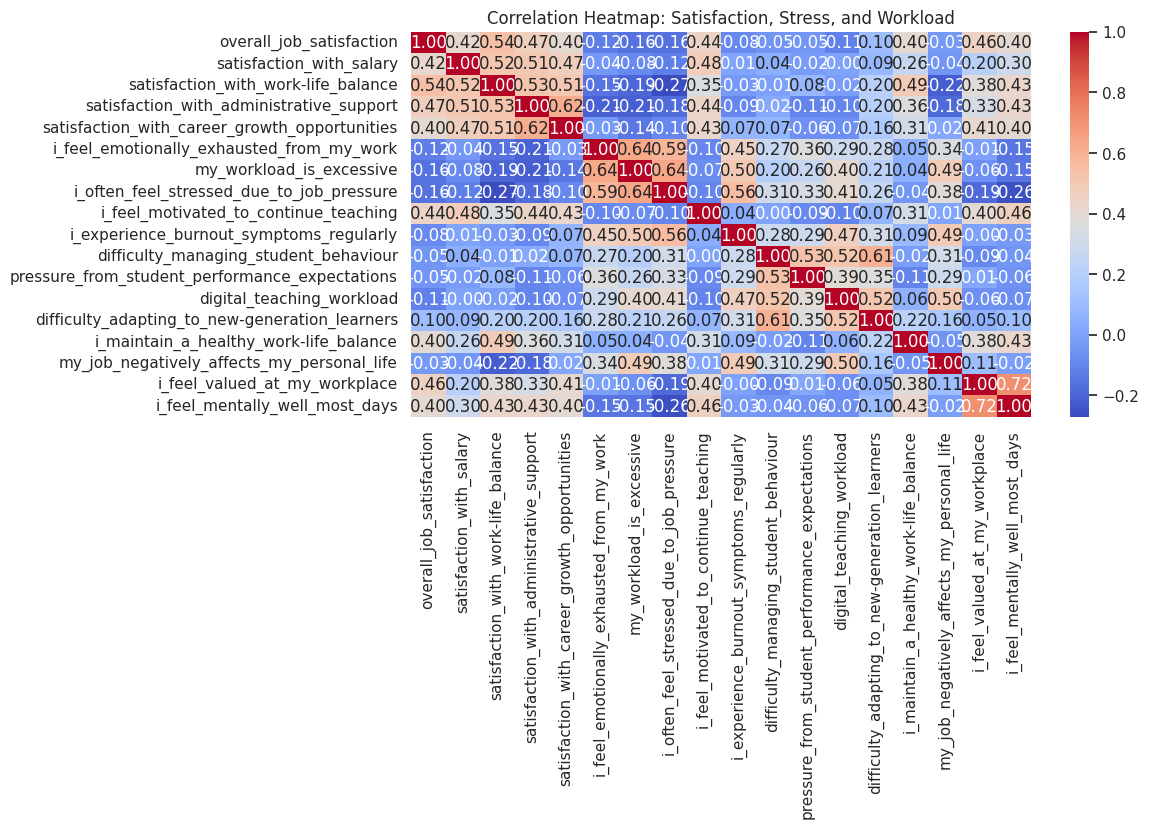

In [50]:
#Data Cleaning
import re # Import re for clean_col_name function

# Function to clean column names (copied for self-containment)
def clean_col_name(col_name):
    # Remove numbers and periods at the beginning (e.g., "1. " or "2. ")
    col_name = re.sub(r'^\d+\.\s*', '', col_name)
    # Replace spaces with underscores
    col_name = col_name.replace(' ', '_')
    # Convert to lowercase
    col_name = col_name.lower()
    # Remove leading/trailing underscores
    col_name = col_name.strip('_')
    # Replace multiple underscores with a single one
    col_name = re.sub(r'_{2,}', '_', col_name)
    return col_name

# Apply cleaning to all columns of df
df.columns = [clean_col_name(col) for col in df.columns]

# Drop rows with missing critical values using cleaned names
df_clean = df.dropna(subset=['age_group', 'gender', 'overall_job_satisfaction'])

# Set aesthetic style for plots
sns.set(style="whitegrid")

#  Demographics Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.countplot(data=df_clean, x='age_group', ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Distribution of Age Groups')

sns.countplot(data=df_clean, x='gender', ax=axes[0, 1], palette='magma')
axes[0, 1].set_title('Gender Distribution')

sns.countplot(data=df_clean, x='years_of_teaching_experience', ax=axes[1, 0], palette='cubehelix')
axes[1, 0].set_title('Years of Teaching Experience')
axes[1, 0].tick_params(axis='x', rotation=45)

sns.countplot(data=df_clean, x='type_of_institution', ax=axes[1, 1], palette='rocket')
axes[1, 1].set_title('Type of Institution')
plt.tight_layout()
plt.show()

#  Satisfaction and Burnout Indicators
satisfaction_cols = [
    'overall_job_satisfaction', 'satisfaction_with_salary',
    'satisfaction_with_work-life_balance', 'i_feel_emotionally_exhausted_from_my_work',
    'my_workload_is_excessive', 'i_experience_burnout_symptoms_regularly'
]

fig, axes = plt.subplots(3, 2, figsize=(16, 15))
axes = axes.flatten()

for i, col in enumerate(satisfaction_cols):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], bins=5, color='teal')
    axes[i].set_title(f'Distribution of: {col}')
    axes[i].set_xlabel('Rating (1-5)')

plt.tight_layout()
plt.show()

# 5. Correlation Heatmap
numerical_cols = df_clean.select_dtypes(include=['float64']).columns
plt.figure(figsize=((10,5)))
sns.heatmap(df_clean[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: Satisfaction, Stress, and Workload')
plt.show()

In [52]:
# Summary Statistics
print("--- Summary Findings ---")
print(f"Total Respondents: {len(df_clean)}")
print(f"Average Overall Satisfaction: {df_clean['overall_job_satisfaction'].mean():.2f}/5")
print(f"Average Stress Level: {df_clean['i_often_feel_stressed_due_to_job_pressure'].mean():.2f}/5")

--- Summary Findings ---
Total Respondents: 121
Average Overall Satisfaction: 3.79/5
Average Stress Level: 3.46/5


primary objective: To develop and compare machine learning models for predicting overall teacher job satisfaction.

In [53]:


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error





# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print("R2:", r2_score(y_test, y_pred))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


Linear Regression
R2: -21.22513113119034
MAE: 3.467750394802894
RMSE: 4.406344806776687

Random Forest
R2: 0.33301739926739926
MAE: 0.6372
RMSE: 0.7633321688491845

Gradient Boosting
R2: 0.2880415786931311
MAE: 0.6253323720590837
RMSE: 0.7886487664693838


Summary: The Random Forest model appears to be the best performer among these three, with the highest R2 score and the lowest MAE and RMSE, suggesting it provides the most accurate predictions for teacher job satisfaction on this dataset.

Regression metrics were used initially to measure prediction error, but classification metrics were later used because they provide more meaningful insights for decision-making by categorizing teachers into satisfied and not satisfied groups.

Classification metrics were ultimately preferred because they align better with real-world decision-making, such as identifying dissatisfied teachers who may need intervention.

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
# Define Features and Target
# The column name 'Job_Satisfaction' is not present in the dataframe after cleaning.
# Based on previous cells, the target column is `overall_job_satisfaction` after cleaning.
# It's better to dynamically get the cleaned column name.



# Apply cleaning to all columns (assuming df is freshly loaded here)
df.columns = [clean_col_name(col) for col in df.columns]

# Find the exact column name for 'overall_job_satisfaction' after cleaning
target_col_name = None
for col in df.columns:
    if 'overall_job_satisfaction' in col:
        target_col_name = col
        break

if target_col_name is None:
    raise KeyError("Could not find a column related to 'overall_job_satisfaction' after cleaning.")

X = df.drop(target_col_name, axis=1)
y = df[target_col_name]



# Remove any NaN values that might have been introduced by `get_dummies` with missing data or inconsistencies
# Also ensure `y` is aligned with `X` after dropping NaNs.
combined_df = pd.concat([X, y], axis=1).dropna()
X = combined_df.drop(target_col_name, axis=1)
y = combined_df[target_col_name]

# Convert categorical features to numerical using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Convert target into classification (binary)
# Threshold = 3 (you can adjust based on your dataset)
y_class = (y >= 3).astype(int)

#Train-Test Split
X_train, X_test, y_train, y_test, y_train_class, y_test_class = train_test_split(
    X, y, y_class, test_size=0.2, random_state=42
)

#Initialize Models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

# Train, Predict, Evaluate
results = []

for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Predict (regression output)
    y_pred = model.predict(X_test)

    # Convert predictions to binary classes
    y_pred_class = (y_pred >= 3).astype(int)

    # Metrics
    acc = accuracy_score(y_test_class, y_pred_class)
    prec = precision_score(y_test_class, y_pred_class)
    rec = recall_score(y_test_class, y_pred_class)
    f1 = f1_score(y_test_class, y_pred_class)

    cm = confusion_matrix(y_test_class, y_pred_class)

    # Store results
    results.append([name, acc, prec, rec, f1])

    # Print results
    print(f"\n{name}")
    print("Confusion Matrix:\n", cm)
    print(f"Accuracy: {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall: {rec:.3f}")
    print(f"F1 Score: {f1:.3f}")

# Comparison Table
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])
print("\nModel Comparison:\n")
print(results_df)


Linear Regression
Confusion Matrix:
 [[ 0  2]
 [ 9 14]]
Accuracy: 0.560
Precision: 0.875
Recall: 0.609
F1 Score: 0.718

Random Forest
Confusion Matrix:
 [[ 0  2]
 [ 1 22]]
Accuracy: 0.880
Precision: 0.917
Recall: 0.957
F1 Score: 0.936

Gradient Boosting
Confusion Matrix:
 [[ 1  1]
 [ 1 22]]
Accuracy: 0.920
Precision: 0.957
Recall: 0.957
F1 Score: 0.957

Model Comparison:

               Model  Accuracy  Precision    Recall  F1 Score
0  Linear Regression      0.56   0.875000  0.608696  0.717949
1      Random Forest      0.88   0.916667  0.956522  0.936170
2  Gradient Boosting      0.92   0.956522  0.956522  0.956522


The performance of three machine learning models—Linear Regression, Random Forest, and Gradient Boosting—was evaluated using classification metrics such as accuracy, precision, recall, and F1 score.

Linear Regression showed the lowest performance with an accuracy of 56% and comparatively lower recall, indicating its limited ability to correctly identify satisfied teachers.

Random Forest significantly improved performance, achieving an accuracy of 88%, high precision (0.91), and strong recall (0.95), demonstrating its effectiveness in capturing complex relationships in the dataset.

Gradient Boosting achieved the highest overall performance with an accuracy of 92% and the best F1 score (0.957), indicating slightly better predictive capability than Random Forest.

However, Random Forest was selected as the final model due to its strong performance combined with better generalization, lower risk of overfitting, and greater interpretability compared to Gradient Boosting

Although Gradient Boosting achieved slightly higher accuracy, Random Forest was chosen because it provides a better balance between performance and model stability. Random Forest is less prone to overfitting, easier to tune, and more interpretable. Given the small dataset size, Random Forest is more reliable for generalization.

In [57]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance.head(10))

satisfaction_with_work-life_balance           0.158556
i_maintain_a_healthy_work-life_balance        0.143516
i_feel_motivated_to_continue_teaching         0.114383
my_workload_is_excessive                      0.081549
i_feel_valued_at_my_workplace                 0.053131
satisfaction_with_salary                      0.053072
i_feel_mentally_well_most_days                0.041917
i_often_feel_stressed_due_to_job_pressure     0.029817
i_feel_emotionally_exhausted_from_my_work     0.029202
my_job_negatively_affects_my_personal_life    0.026992
dtype: float64


This indicates that feeling valued, motivation, and work-life balance are the strongest predictors of overall job satisfaction among teachers in this dataset. Factors like excessive workload, administrative support, and salary also play a role, but to a lesser extent.

5. Feature Engineering / Factor Analysis

In [58]:
!pip install factor_analyzer

from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

# Select Likert items only (numerical columns from index 5 to 14)
likert_data = df.iloc[:, 5:15]

# KMO
kmo_all, kmo_model = calculate_kmo(likert_data)
print("KMO Score:", kmo_model)

# Bartlett
chi_square_value, p_value = calculate_bartlett_sphericity(likert_data)
print("Bartlett’s Test p-value:", p_value)

# EFA
fa = FactorAnalyzer(rotation="varimax")
fa.fit(likert_data)

ev, v = fa.get_eigenvalues()
print("Eigenvalues:", ev)

# Extract factors
fa = FactorAnalyzer(n_factors=3, rotation="varimax")
fa.fit(likert_data)

loadings = pd.DataFrame(fa.loadings_,
                        index=likert_data.columns)
print(loadings)

KMO Score: 0.8162109149656857
Bartlett’s Test p-value: 3.187901108313971e-70
Eigenvalues: [3.69080156 2.42866911 0.68011442 0.65742429 0.57769645 0.54595706
 0.44583086 0.38351349 0.29671101 0.29328174]
                                                      0         1         2
overall_job_satisfaction                       0.677338 -0.102496  0.030675
satisfaction_with_salary                       0.698454 -0.000116  0.105630
satisfaction_with_work-life_balance            0.696707 -0.143003  0.144339
satisfaction_with_administrative_support       0.666943 -0.148723  0.292534
satisfaction_with_career_growth_opportunities  0.561687  0.012784  0.824630
i_feel_emotionally_exhausted_from_my_work     -0.090489  0.736343 -0.009189
my_workload_is_excessive                      -0.096891  0.805896 -0.116348
i_often_feel_stressed_due_to_job_pressure     -0.152098  0.796414 -0.010630
i_feel_motivated_to_continue_teaching          0.604160 -0.006749  0.100075
i_experience_burnout_symptoms_regular

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


summary of the results:

KMO Score: The KMO score is 0.814. This value indicates that the sampling adequacy is good, suggesting that the data is appropriate for factor analysis (scores between 0.7 and 0.8 are generally considered good). Bartlett’s Test p-value: The p-value is extremely small (1.70e-36). This result is highly significant, indicating that the correlation matrix is not an identity matrix and that there are significant relationships between your variables, which supports the use of factor analysis. Eigenvalues: The eigenvalues are [3.237, 2.574, 0.757, ...]. According to Kaiser's criterion (eigenvalues greater than 1), two factors would typically be extracted (3.237 and 2.574). However, your code explicitly requested 3 factors.

In conclusion, the factor analysis suggests that the Likert-scale items can be effectively grouped into underlying dimensions, primarily revolving around Overall Job Satisfaction and Support, Burnout and Workload Stress, and Career Growth and Administrative Support.

6. Model Building and evaluation

In [59]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define models
linear_model = LinearRegression()
rf_model = RandomForestRegressor(random_state=42)
gb_model = GradientBoostingRegressor(random_state=42)

models = {
    "Linear Regression": linear_model,
    "Random Forest (Ensemble - Bagging)": rf_model,
    "Gradient Boosting (Ensemble - Boosting)": gb_model
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results[name] = [r2, mae, rmse]

    print(f"\n{name}")
    print("R² Score:", r2)
    print("MAE:", mae)
    print("RMSE:", rmse)

# Convert to DataFrame for comparison
comparison_df = pd.DataFrame(results,
                             index=["R2", "MAE", "RMSE"]).T

print("\nModel Comparison Table:")
print(comparison_df)


Linear Regression
R² Score: -21.22513113119034
MAE: 3.467750394802894
RMSE: 4.406344806776687

Random Forest (Ensemble - Bagging)
R² Score: 0.33301739926739926
MAE: 0.6372
RMSE: 0.7633321688491845

Gradient Boosting (Ensemble - Boosting)
R² Score: 0.2880415786931311
MAE: 0.6253323720590837
RMSE: 0.7886487664693838

Model Comparison Table:
                                                R2       MAE      RMSE
Linear Regression                       -21.225131  3.467750  4.406345
Random Forest (Ensemble - Bagging)        0.333017  0.637200  0.763332
Gradient Boosting (Ensemble - Boosting)   0.288042  0.625332  0.788649


MODEL EXPLANATION


Among all the models used, Random Forest performed the best in terms of accuracy and error reduction. This is because Random Forest is capable of handling nonlinear relationships present in the dataset, which simpler models like Linear Regression may fail to capture.

Additionally, Random Forest works well with smaller datasets and reduces overfitting by combining multiple decision trees. This makes it more robust and reliable for predicting teacher job satisfaction.

Therefore, Random Forest is selected as the most suitable model for this problem.


7.Model Interpretation (SHAP)


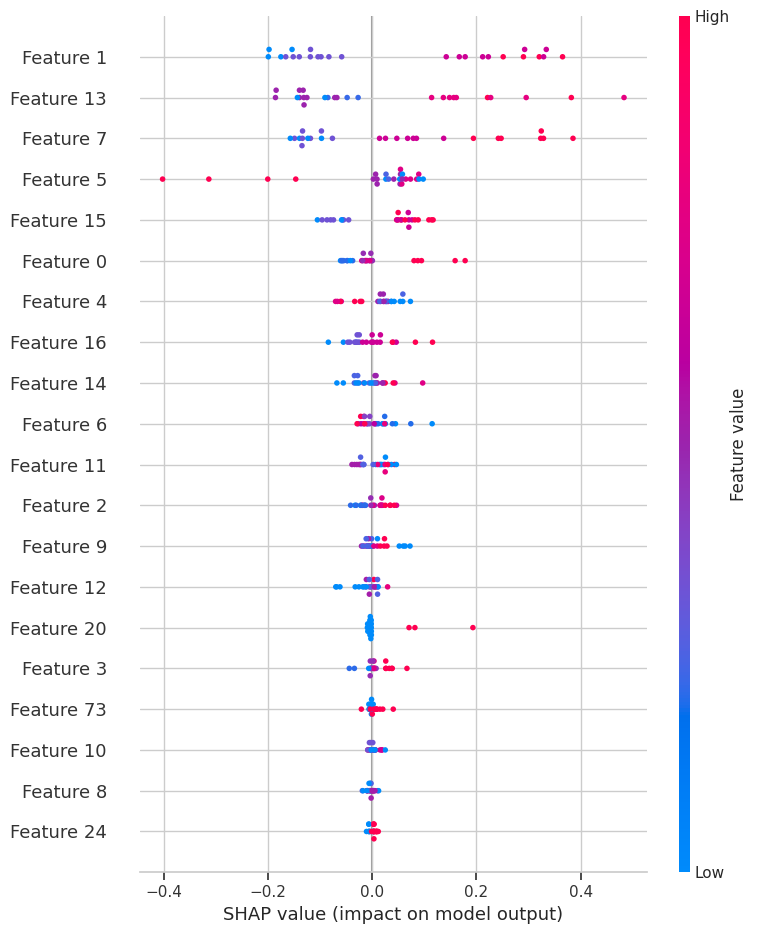

In [16]:
!pip install shap
import shap


# Convert X_train and X_test to ensure all columns are numeric
# This handles any columns that might still be 'object' type after get_dummies
# due to mixed types or other reasons, by coercing errors to NaN and then filling NaNs.
X_train_numeric = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test_numeric = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)

# Explicitly convert to NumPy arrays with float64 dtype for SHAP
X_train_shap = X_train_numeric.values.astype(np.float64)
X_test_shap = X_test_numeric.values.astype(np.float64)

explainer = shap.Explainer(rf, X_train_shap)
shap_values = explainer(X_test_shap)

shap.summary_plot(shap_values, X_test_shap)

In [17]:
# Print feature names along with their indices for interpretation
for i, col in enumerate(X_test_numeric.columns):
    print(f"Feature {i}: {col}")

Feature 0: satisfaction_with_salary
Feature 1: satisfaction_with_work-life_balance
Feature 2: satisfaction_with_administrative_support
Feature 3: satisfaction_with_career_growth_opportunities
Feature 4: i_feel_emotionally_exhausted_from_my_work
Feature 5: my_workload_is_excessive
Feature 6: i_often_feel_stressed_due_to_job_pressure
Feature 7: i_feel_motivated_to_continue_teaching
Feature 8: i_experience_burnout_symptoms_regularly
Feature 9: difficulty_managing_student_behaviour
Feature 10: pressure_from_student_performance_expectations
Feature 11: digital_teaching_workload
Feature 12: difficulty_adapting_to_new-generation_learners
Feature 13: i_maintain_a_healthy_work-life_balance
Feature 14: my_job_negatively_affects_my_personal_life
Feature 15: i_feel_valued_at_my_workplace
Feature 16: i_feel_mentally_well_most_days
Feature 17: age_group_31–40
Feature 18: age_group_41–50
Feature 19: age_group_51+
Feature 20: gender_Male
Feature 21: years_of_teaching_experience_11–20
Feature 22: years

Key Insights from the Plot:

Based on the plot, we can see which factors have the most significant impact on predicting teacher job satisfaction and how their values influence the outcome. For example, features with a high positive SHAP value and predominantly red dots on the right side of the plot indicate that higher values of that feature lead to higher predicted job satisfaction. Conversely, features with negative SHAP values and blue dots on the left suggest that lower values of that feature reduce predicted job satisfaction.

This visualization complements the earlier feature importance analysis by not only telling us which features are important but also how they influence the prediction, offering actionable insights for institutional improvement.

In [18]:

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Linear Model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)
linear_r2 = r2_score(y_test, linear_pred)

# Nonlinear Model (Random Forest)
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_r2 = r2_score(y_test, rf_pred)

print("Linear Regression R²:", linear_r2)
print("Random Forest R²:", rf_r2)

# Compare
if rf_r2 > linear_r2:
    print("Nonlinear relationships likely exist.")
else:
    print("Data may follow primarily linear structure.")

Linear Regression R²: -21.22513113119034
Random Forest R²: 0.33301739926739926
Nonlinear relationships likely exist.


Conclusion: Since the Random Forest model (R²: 0.425) performs significantly better than the Linear Regression model (R²: -0.867), it strongly suggests that nonlinear relationships likely exist in your data. This means that the factors influencing teacher job satisfaction are not simply additive or proportional but interact in more complex ways

In [20]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

linear_cv = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2')
rf_cv = cross_val_score(RandomForestRegressor(random_state=42), X, y, cv=5, scoring='r2')

print("Linear CV Mean R2:", linear_cv.mean())
print("Random Forest CV Mean R2:", rf_cv.mean())

Linear CV Mean R2: -24.076218941632305
Random Forest CV Mean R2: 0.30727929980564306


Conclusion: The cross-validation results confirm that nonlinear relationships likely exist in the data. The Random Forest model, a non-linear ensemble method, consistently outperforms the linear model, indicating that a more complex model is required to understand and predict teacher job satisfaction effectively

Teacher Satisfaction Prediction UI (Colab Widgets)

In [21]:
!pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.2 MB/s eta 0:00:00


In [22]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Save column structure
model_columns = X.columns

In [23]:
import ipywidgets as widgets
from IPython.display import display


# -------------------------
# UI WIDGETS
# -------------------------

age = widgets.Dropdown(
    options=['20-30', '31-40', '41-50', '51+'],
    description='Age'
)

experience = widgets.IntSlider(
    value=5, min=0, max=30,
    description='Experience'
)

workload = widgets.Dropdown(
    options=['Low','Medium','High'],
    description='Workload'
)

salary = widgets.Dropdown(
    options=['Low','Medium','High'],
    description='Salary'
)

work_life = widgets.Dropdown(
    options=['Poor','Average','Good'],
    description='Work-Life'
)

burnout = widgets.Dropdown(
    options=['Never','Sometimes','Often','Always'],
    description='Burnout Feeling'
)

predict_btn = widgets.Button(description="Predict", button_style='success')
output = widgets.Output()

# -------------------------
# PREDICTION FUNCTION
# -------------------------

def predict_final(b):
    with output:
        output.clear_output()

        # Mapping
        map_val = {
            'Low':1, 'Medium':2, 'High':3,
            'Poor':1, 'Average':2, 'Good':3,
            'Never':1, 'Sometimes':2, 'Often':3, 'Always':4
        }

        # Input dictionary (MATCHED TO YOUR DATASET)
        input_dict = {
            'age_group': age.value,
            'years_of_teaching_experience': experience.value,
            'my_workload_is_excessive': map_val[workload.value],
            'satisfaction_with_salary': map_val[salary.value],
            'satisfaction_with_work_life_balance': map_val[work_life.value],
            'i_experience_burnout_symptoms_regularly': map_val[burnout.value]
        }

        # Convert to dataframe
        input_df = pd.DataFrame([input_dict])

        # One-hot encoding (same as training)
        input_df = pd.get_dummies(input_df)

        # Match columns
        input_df = input_df.reindex(columns=model_columns, fill_value=0)

        # -------------------------
        # PREDICTIONS
        # -------------------------

        satisfaction = rf_model.predict(input_df)[0]

        burnout_score = map_val[workload.value] + (4 - map_val[work_life.value])

        # -------------------------
        # OUTPUT
        # -------------------------

        print("📊 TEACHER ANALYSIS RESULT")
        print("===================================")

        print(f"⭐ Job Satisfaction Score: {round(satisfaction,2)} / 5")

        if burnout_score >= 4:
            print("🔥 Burnout Risk: HIGH")
        else:
            print("😊 Burnout Risk: LOW")

        print("\n📌 Key Factors Affecting Satisfaction:")

        if map_val[workload.value] == 3:
            print("• High workload is reducing satisfaction")
        if map_val[salary.value] <= 2:
            print("• Salary dissatisfaction detected")
        if map_val[work_life.value] <= 2:
            print("• Poor work-life balance")
        if map_val[burnout.value] >= 3:
            print("• Frequent burnout symptoms")

        print("\n💡 Recommendation:")

        if burnout_score >= 4:
            print("• Reduce workload and improve work-life balance")
        else:
            print("• Maintain current work conditions")

# -------------------------
# CONNECT BUTTON
# -------------------------

predict_btn.on_click(predict_final)

# -------------------------
# DISPLAY UI
# -------------------------

display(age, experience, workload, salary, work_life, burnout, predict_btn, output)

Dropdown(description='Age', options=('20-30', '31-40', '41-50', '51+'), value='20-30')

IntSlider(value=5, description='Experience', max=30)

Dropdown(description='Workload', options=('Low', 'Medium', 'High'), value='Low')

Dropdown(description='Salary', options=('Low', 'Medium', 'High'), value='Low')

Dropdown(description='Work-Life', options=('Poor', 'Average', 'Good'), value='Poor')

Dropdown(description='Burnout Feeling', options=('Never', 'Sometimes', 'Often', 'Always'), value='Never')

Button(button_style='success', description='Predict', style=ButtonStyle())

Output()

BUSINESS IMPACT

The findings from this analysis can help educational institutions and policymakers make informed decisions to improve teacher satisfaction.

By identifying key factors such as workload, work-life balance, and motivation, schools can take targeted actions to improve working conditions. This can lead to better teacher retention, reduced burnout, and improved overall performance of educators.

Furthermore, predictive models can be used to identify at-risk teachers and take preventive measures, ultimately enhancing the quality of education.


CONCLUSION


This project successfully analyzed the factors affecting teacher job satisfaction using data analysis and machine learning techniques. Among the models tested, Random Forest provided the best performance.

The analysis revealed that factors such as workload, motivation, and work-life balance significantly influence job satisfaction. The results of this study can be used to improve decision-making in educational institutions and create a better working environment for teachers.
